In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


stock_data = pd.read_csv("portfolio_data.csv", header=0, sep=",")
print(stock_data.head())
print(stock_data.info())
print(stock_data.describe())

       Date        AMZN        DPZ         BTC       NFLX
0  5/1/2013  248.229996  51.190983  106.250000  30.415714
1  5/2/2013  252.550003  51.987320   98.099998  30.641428
2  5/3/2013  258.049988  52.446388  112.900002  30.492857
3  5/6/2013  255.720001  53.205257  109.599998  30.098572
4  5/7/2013  257.730011  54.151505  113.199997  29.464285
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   object 
 1   AMZN    1520 non-null   float64
 2   DPZ     1520 non-null   float64
 3   BTC     1520 non-null   float64
 4   NFLX    1520 non-null   float64
dtypes: float64(4), object(1)
memory usage: 59.5+ KB
None
              AMZN          DPZ           BTC         NFLX
count  1520.000000  1520.000000   1520.000000  1520.000000
mean    821.541810   146.771695   2421.465669   147.668273
std     518.442653    72.192287   3310.894199   107.

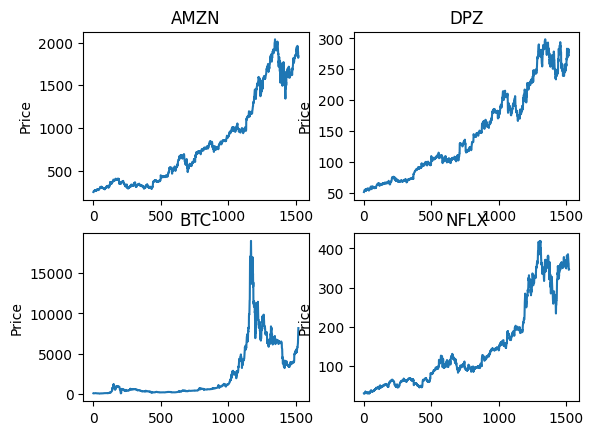

In [ ]:
#  change in price of the stock overtime
stock_list = ["AMZN", "DPZ", "BTC", "NFLX"]
color_list = ["gold", "red", "skyblue", "green"]
for i, stock in enumerate(stock_list, 1):
    plt.subplot(2,2,i)
    stock_data[stock].plot()
    # plt.plot(stock_data["Date"], stock_data[stock], color_list[i-1])
    # plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title(stock)

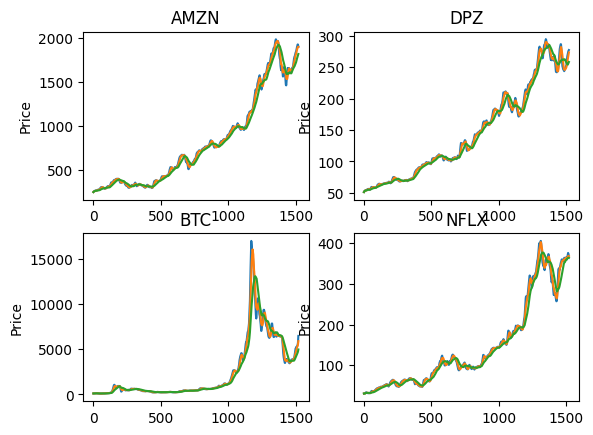

In [ ]:
# the moving average of the various stocks
ma_day = [10,20,50]
stock_dic = {}
for stock in stock_list:
    stock_dic[stock] = {}
    for ma in ma_day:
        col_name = f"MA for {ma} days"
        stock_dic[stock][col_name] = stock_data[stock].rolling(window=ma, min_periods=1).mean()

# print(stock_dic)

for i , stock in enumerate(stock_list, 1):
    plt.subplot(2,2,i)
    plt.ylabel("Price")
    plt.title(stock)
    for ma in ma_day:
        col_name = f"MA for {ma} days"
        stock_dic[stock][col_name].plot()

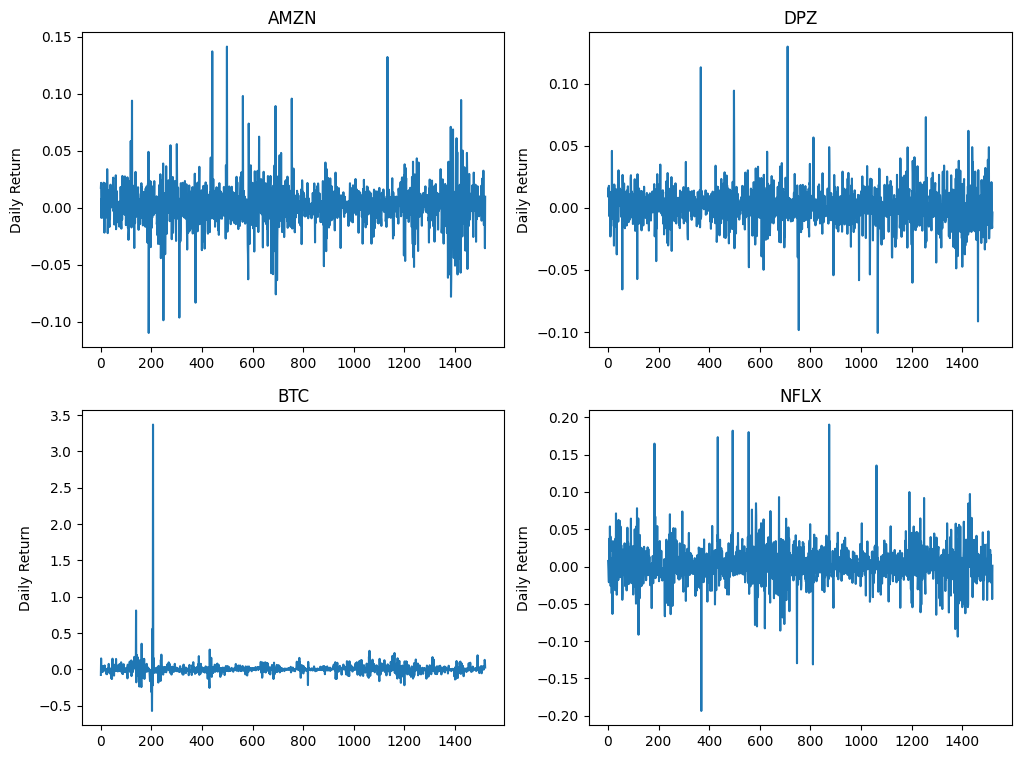

In [18]:
#What was the daily return of the stock on average?
plt.figure(figsize=(12, 9))
daily_ret_dic = {}
for stock in stock_list:
    daily_ret_dic[stock] = stock_data[stock].pct_change()

for i , stock in enumerate(stock_list, 1):
    plt.subplot(2,2,i)
    plt.ylabel("Daily Return")
    plt.title(stock)
    daily_ret_dic[stock].plot()



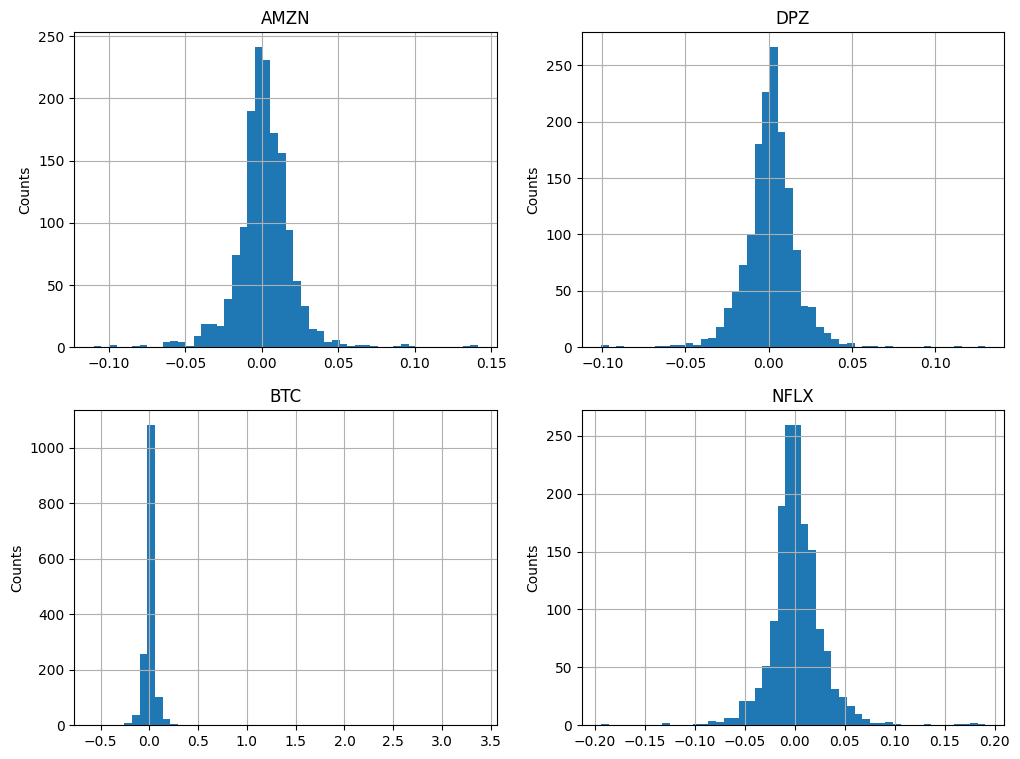

In [ ]:
# Histogram of daily return
plt.figure(figsize=(12, 9))
for i, stock in enumerate(stock_list, 1):
    plt.subplot(2,2,i)
    plt.ylabel("Counts")
    plt.title(stock)
    daily_ret_dic[stock].hist(bins=50)
    

TypeError: 'data' must be pandas DataFrame object, not: <class 'dict'>

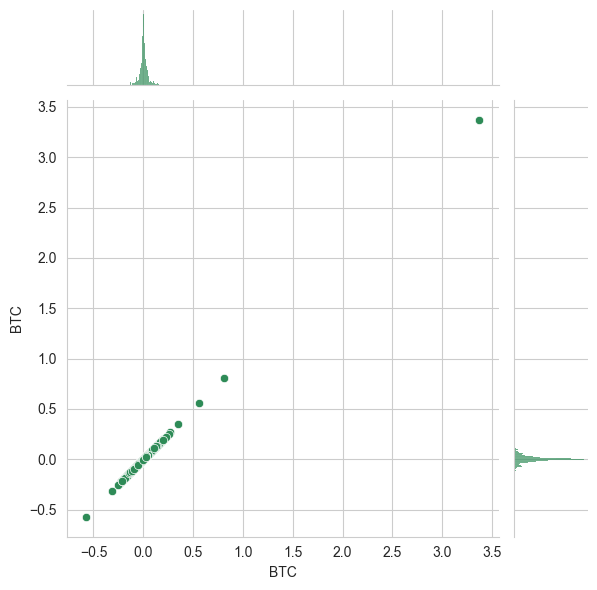

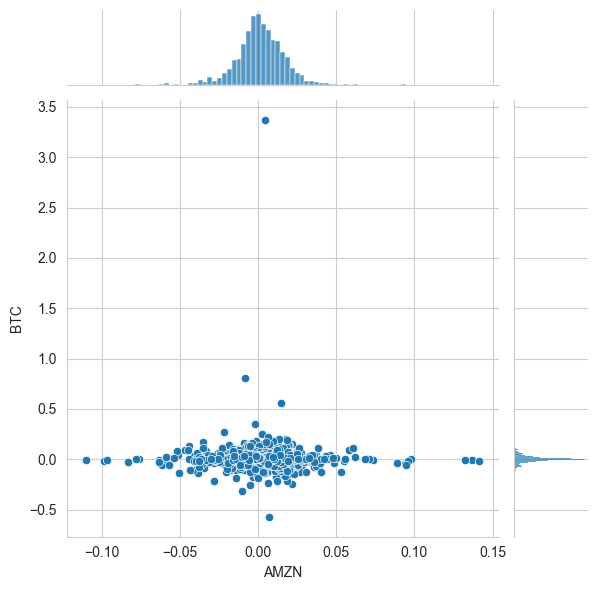

In [ ]:
# What was the correlation between different stocks prices?
import seaborn as sns
sns.set_style('whitegrid')
# print(daily_ret_dic.items())
# daily_ret_df = pd.DataFrame(list(daily_ret_dic.items()), columns=['Date', ''])
# daily_ret_df.head()
sns.jointplot(x='BTC', y='BTC', data=daily_ret_dic, kind='scatter', color='seagreen')
sns.jointplot(x='AMZN', y='BTC', data=daily_ret_dic, kind='scatter')
# sns.pairplot(daily_ret_dic, kind='reg')